# A Reproducibility Study: Discover-then-Name

**Rao, S., Mahajan, S., Böhle, M., & Schiele, B. (2024).** *Discover-then-Name: Task-Agnostic Concept Bottlenecks via Automated Concept Discovery.* In *Proceedings of the European Conference on Computer Vision (ECCV).*

**By:** Federica Valeau, Eduardo Terres, Davide Pasero, Kiki van Gerwen  
**Affiliation:** University of Amsterdam

## Introduction
In this notebook, we provide a brief tour of our different research methods.

We trained a Sparse Autoencoder on the [CC3M dataset](https://ai.google.com/research/ConceptualCaptions/download) and aligned the concept space with the `20k.txt` vocabulary, a list of the most common English words. You can download it from [here](https://github.com/first20hours/google-10000-english/blob/master/20k.txt).


Install LaTeX

In [ ]:
!apt-get install -y texlive-latex-extra texlive-fonts-recommended dvipng cm-super

Get trained Models from Google Drive and some data and figures

In [ ]:
# Trained model
!gdown --id 16Zl79snAulIlrLp5ivjjDNupXAPSEseV -O sparse_autoencoder_final.pt
!gdown --id 1rARrZR0suDEPPAg-GPdIJZKYI99KAg_P -O probe_cifar10.pt
!gdown --id 1WRbX9J9UzYyVxThR-i6dSLei0efL3im1 -O modified_probe_cifar10.pt
!gdown --id 1BFiixYG-z6DdCGKtd_D_Cq18hzfQ94vE -O all_labels_val.pth
!gdown --id 17juJz-wccu52t4nLGGr04ju4qC-2YZP0 -O all_concepts.pth
!gdown --id 1HPQ-jrnCafAjLfy5NeXZHcy6BXWRtMci -O concept_names.csv
# Data and figures
!gdown --folder --id 1h6gnK3jI3KSAdx6TxIRpbIepOKEJTCX9 -O /content/
!gdown --folder --id 1CofAu0zFrXLIQQG3938PbWJvjC4C4fe- -O /content/

In [4]:
# Unzip wordnet_checkpoints
import zipfile
with zipfile.ZipFile("/content/data/wordnet_chkpts.zip", "r") as zip_ref:
    zip_ref.extractall("/content/data/")

In [5]:
!git clone https://github.com/neuroexplicit-saar/Discover-then-Name.git
!mv Discover-then-Name DiscoverThenName

Cloning into 'Discover-then-Name'...
remote: Enumerating objects: 229, done.
remote: Counting objects: 100% (229/229), done.
remote: Compressing objects: 100% (194/194), done.
remote: Total 229 (delta 28), reused 214 (delta 18), pack-reused 0 (from 0)
Receiving objects: 100% (229/229), 1.62 MiB | 15.76 MiB/s, done.
Resolving deltas: 100% (28/28), done.


## Import libraries from repository


In [6]:
import torch
import torchvision
import torch.utils.data
import torchvision.transforms as transforms
from torch.utils.data import TensorDataset
import csv
import pandas as pd
import matplotlib.pyplot as plt

#%cd /content/Discover-then-Name

import sys
repo_path = "/content/Discover-then-Name"
if repo_path not in sys.path:
    sys.path.append(repo_path)

from DiscoverThenName.dncbm.data_utils.probe_classnames import probe_classes_dict

device = "cuda" if torch.cuda.is_available() else "cpu"

# Download and load CIFAR-10 dataset
#trainset = torchvision.datasets.CIFAR10(root="./data", train=True, download=True)
#testset = torchvision.datasets.CIFAR10(root="./data", train=False, download=True)


## **Evaluating a Linear Probe on CIFAR-10**
The following code loads a trained model and evaluates its **top-1 accuracy** on the **CIFAR-10 test set**. The evaluation is performed using the function `eval_top1_accuracy`.

### **Evaluation Process:**
- **Load the trained model** in evaluation mode.
- **Compute top-1 accuracy**, where the model's highest-confidence prediction is compared to the ground-truth label.
- **Return the final accuracy score** as a float.

### **Concept Mapping:**
Additionally, the function `read_concept_names` is provided to **map concept indices to their corresponding names** from 'concept_names.csv'.


In [ ]:
import torch
from tqdm import tqdm

def eval_top1_accuracy(model, loader, device):
    """
    Computes top-1 accuracy of a classification model.

    Args:
        model (torch.nn.Module): The trained model.
        loader (torch.utils.data.DataLoader): DataLoader for evaluation.
        device (torch.device): Device (CPU or CUDA).

    Returns:
        float: Computed top-1 accuracy.
    """
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for test_X, test_y in tqdm(loader, desc="Evaluating"):
            test_X, test_y = test_X.to(device), test_y.to(device)
            out = model(test_X)  # Model predictions

            predicted = torch.argmax(out, dim=1)  # Get top-1 class predictions
            correct += (predicted == test_y).sum().item()  # Count correct predictions
            total += test_y.size(0)  # Total samples

    return correct / total  # Top-1 accuracy as a float

def read_concept_names(file_path):
    """
    Reads the concept index-to-name mapping from a CSV file.

    Args:
        file_path (str): Path to the CSV file containing concept names.

    Returns:
        dict: A dictionary mapping concept indices to concept names.
    """
    concept_mapping = {}
    with open(file_path, "r") as f:
        reader = csv.reader(f)
        for row in reader:
            idx, name = int(row[0]), row[1]
            concept_mapping[idx] = name
    return concept_mapping

## **Visualization of Model Performance**

The figure below presents the **top-1 accuracy** of the model on the **CIFAR-10 test set** over **200 evaluation steps**, ending at an accruacy of **88.31%**


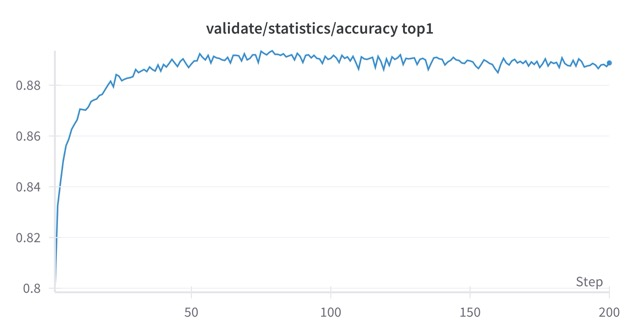

In [ ]:
num_concepts = 8192
num_classes = 10
test_data = torch.load("content/all_concepts.pth")
test_labels = torch.load("content/all_labels_val.pth")

test_dataset = TensorDataset(test_data, test_labels)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=512, shuffle=False)
model = torch.nn.Linear(num_concepts, num_classes, bias=False)
model = model.train().to(device)
state_dict_path = "content/probe_cifar10.pt"

checkpoint = torch.load(state_dict_path, map_location=device)
state_dict = checkpoint['model']  # Extract only the model weights

concept_mapping = read_concept_names("content/concept_names.csv")

model.load_state_dict(state_dict)

test_accuracy = eval_top1_accuracy(model, test_loader, device)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

<ipython-input-15-832000564ffb>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  test_data = torch.load("content/all_concepts.pth")
<ipython-input-15-832000564ffb>:4: Future

Test Accuracy: 88.31%


Get top-k biggest weights, which are the weights the model relies on the most. They are plotted below with their concept names.

In [ ]:
def get_top_k_biggest_weights (model, k=10):
    """
    Get the top-k biggest weights for each class in the model.

    Args:
        args (argparse.Namespace): Command-line arguments.
        model (torch.nn.Module): Linear model with weights.
        k (int): Number of top weights to display.
    """
    class_names = probe_classes_dict["cifar10"]
    top_k_weights_indices = {}
    with torch.no_grad():
        for class_idx in range(num_classes):
            class_weights = model.weight[class_idx, :]
            top_indices = torch.topk(class_weights, k=k).indices
            top_k_weights_indices[class_names[class_idx]] = top_indices.tolist()
    return top_k_weights_indices

In [ ]:
top_k_biggest_weights = get_top_k_biggest_weights (model, k=5)
# Convert the dictionary into a pandas DataFrame
data = {
    "Class Name": [class_name.capitalize() for class_name in top_k_biggest_weights.keys()],
    "Top-k Concepts": [
        [concept_mapping[concept_idx] for concept_idx in concepts]  # Convert indices to names
        for concepts in top_k_biggest_weights.values()
    ],
}


# Create DataFrame
df_top_k_concepts = pd.DataFrame(data)

# Display the DataFrame
df_top_k_concepts

Class Name: ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']
Top-k Concepts: [['interchange', 'lobster', 'lips', 'blue', 'sauna'], ['hay', 'infrared', 'belts', 'chevelle', 'compartment'], ['wires', 'branches', 'yellowstone', 'lips', 'wheat'], ['altar', 'expire', 'wildcats', 'permitted', 'lion'], ['tree', 'profile', 'supernatural', 'chairs', 'yoga'], ['feeds', 'irene', 'cymru', 'backpacking', 'gloves'], ['electrode', 'grass', 'robe', 'browning', 'dotted'], ['theatres', 'assemblies', 'schwarzenegger', 'vineyards', 'turner'], ['folds', 'interchange', 'hogtied', 'lacrosse', 'hopper'], ['hopper', 'butterflies', 'tetris', 'apartment', 'panel']]


,Class Name,Top-k Concepts
0,Airplane,"[interchange, lobster, lips, blue, sauna]"
1,Automobile,"[hay, infrared, belts, chevelle, compartment]"
2,Bird,"[wires, branches, yellowstone, lips, wheat]"
3,Cat,"[altar, expire, wildcats, permitted, lion]"
4,Deer,"[tree, profile, supernatural, chairs, yoga]"
5,Dog,"[feeds, irene, cymru, backpacking, gloves]"
6,Frog,"[electrode, grass, robe, browning, dotted]"
7,Horse,"[theatres, assemblies, schwarzenegger, vineyar..."
8,Ship,"[folds, interchange, hogtied, lacrosse, hopper]"
9,Truck,"[hopper, butterflies, tetris, apartment, panel]"


## **Evaluating a Linear Probe on CIFAR-10 (with modified loss)**

$\mathcal{L}_{\text{total}}(\mathbf{w}) = \mathcal{L}_{\text{class}}(\mathbf{w}, \mathbf{x}, y) + \lambda_{\text{spar}} \mathcal{L}_{\text{spar}}(\mathbf{w}) + \lambda_{\text{penalty}} \mathcal{L}_{\text{penalty}}(\mathbf{w}, y),$

The third term of the loss is the one that has been added by us in order to make the linear probe rely more on relevant concepts (with respect to the class names) with the aim of removing spurious correlations during inference time. This makes the model capable of generalizing to diverse settings and backgrounds, it makes the model more explainable and doesn't sacrifice too much performance on standard unbiased dataset (where correlations helps with the classification).

In [ ]:
modified_model = torch.nn.Linear(num_concepts, num_classes, bias=False)
modified_model = modified_model.train().to(device)
state_dict_path = "content/modified_probe_cifar10.pt"

checkpoint = torch.load(state_dict_path, map_location=device)
state_dict = checkpoint['model']
modified_model.load_state_dict(state_dict)

test_accuracy = eval_top1_accuracy(modified_model, test_loader, device)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

<ipython-input-19-7dab81ff81a7>:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(state_dict_path, map_location=device)
Evaluating: 100%|██████████| 2

Test Accuracy: 86.42%


In [ ]:
top_k_biggest_weights = get_top_k_biggest_weights (modified_model, k=5)

# Convert the dictionary into a pandas DataFrame
data = {
    "Class Name": [class_name.capitalize() for class_name in top_k_biggest_weights.keys()],
    "Top-k Concepts": [
        [concept_mapping[concept_idx] for concept_idx in concepts]  # Convert indices to names
        for concepts in top_k_biggest_weights.values()
    ],
}

for class_name, concepts in data.items():
    print(f"{class_name}: {concepts}")

# Create DataFrame
df_top_k_concepts = pd.DataFrame(data)

# Display the DataFrame
df_top_k_concepts

Class Name: ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']
Top-k Concepts: [['interchange', 'airplanes', 'airlines', 'corsair', 'stars'], ['car', 'chevelle', 'police', 'trucks', 'corvette'], ['birds', 'beavers', 'owl', 'playground', 'sparrow'], ['worldcat', 'patriotic', 'huskies', 'kendall', 'irene'], ['elk', 'turner', 'tree', 'yellowstone', 'deer'], ['dogs', 'yves', 'panda', 'singh', 'orchid'], ['crocodile', 'lime', 'green', 'embryo', 'mosaic'], ['horseback', 'balcony', 'casper', 'pegasus', 'restoration'], ['yacht', 'canoeing', 'ferries', 'surfer', 'qc'], ['tractor', 'tetris', 'hopper', 'swiss', 'lego']]


,Class Name,Top-k Concepts
0,Airplane,"[interchange, airplanes, airlines, corsair, st..."
1,Automobile,"[car, chevelle, police, trucks, corvette]"
2,Bird,"[birds, beavers, owl, playground, sparrow]"
3,Cat,"[worldcat, patriotic, huskies, kendall, irene]"
4,Deer,"[elk, turner, tree, yellowstone, deer]"
5,Dog,"[dogs, yves, panda, singh, orchid]"
6,Frog,"[crocodile, lime, green, embryo, mosaic]"
7,Horse,"[horseback, balcony, casper, pegasus, restorat..."
8,Ship,"[yacht, canoeing, ferries, surfer, qc]"
9,Truck,"[tractor, tetris, hopper, swiss, lego]"


#Visualizations

Task Agnosticity

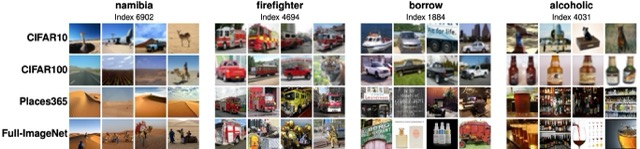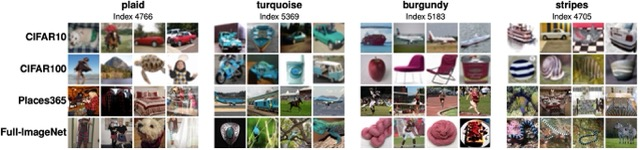

Meta clusters

**CIFAR10**
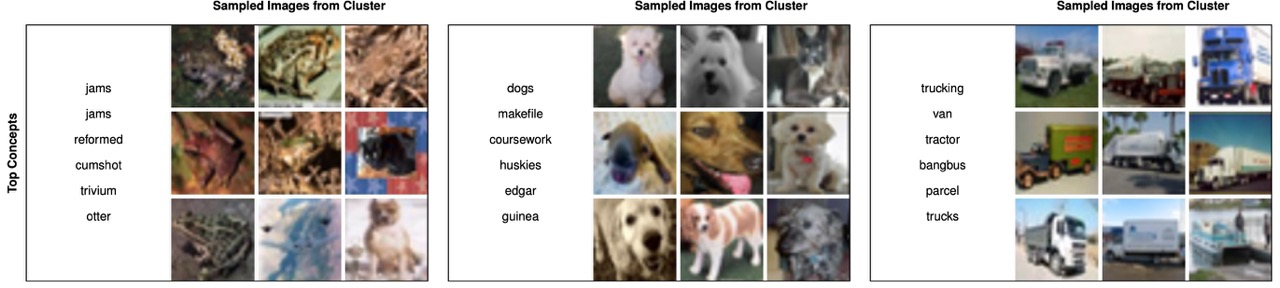

**CIFAR100**
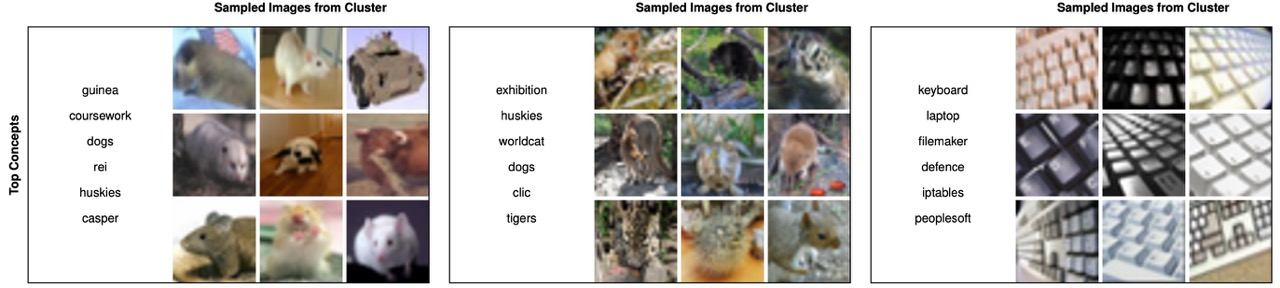

**ImageNet**
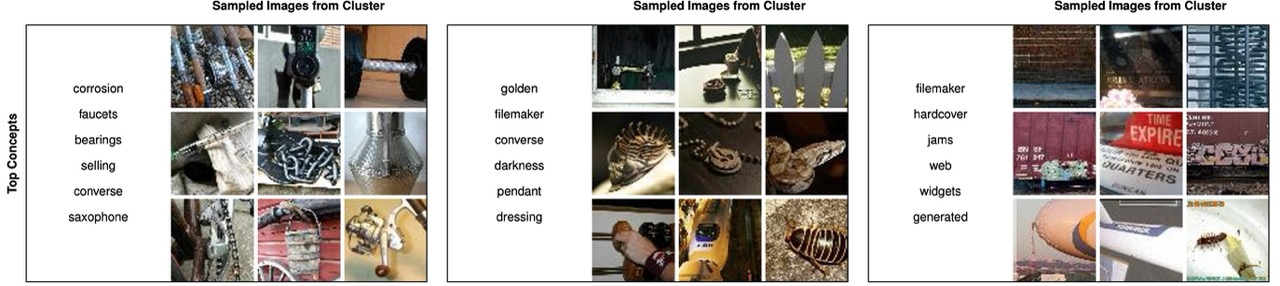

**Places365**
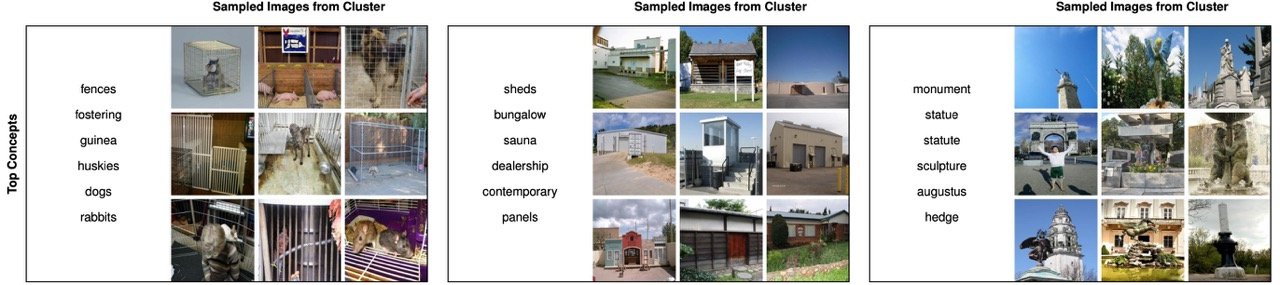

Local explanations

**CIFAR10**
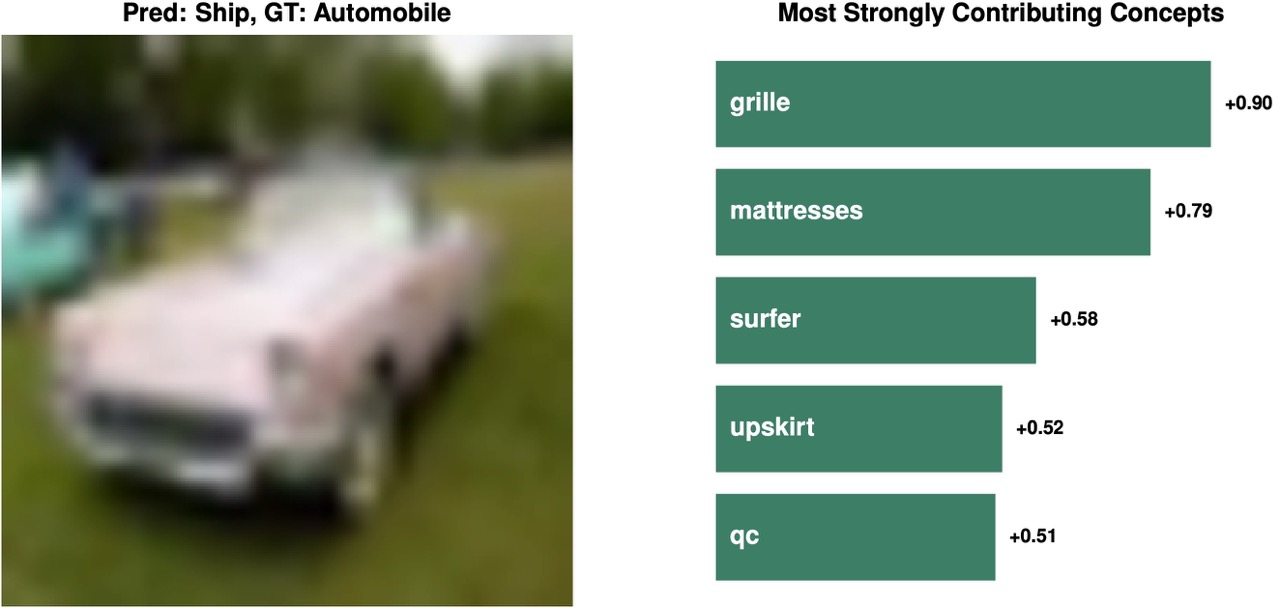

**CIFAR100**
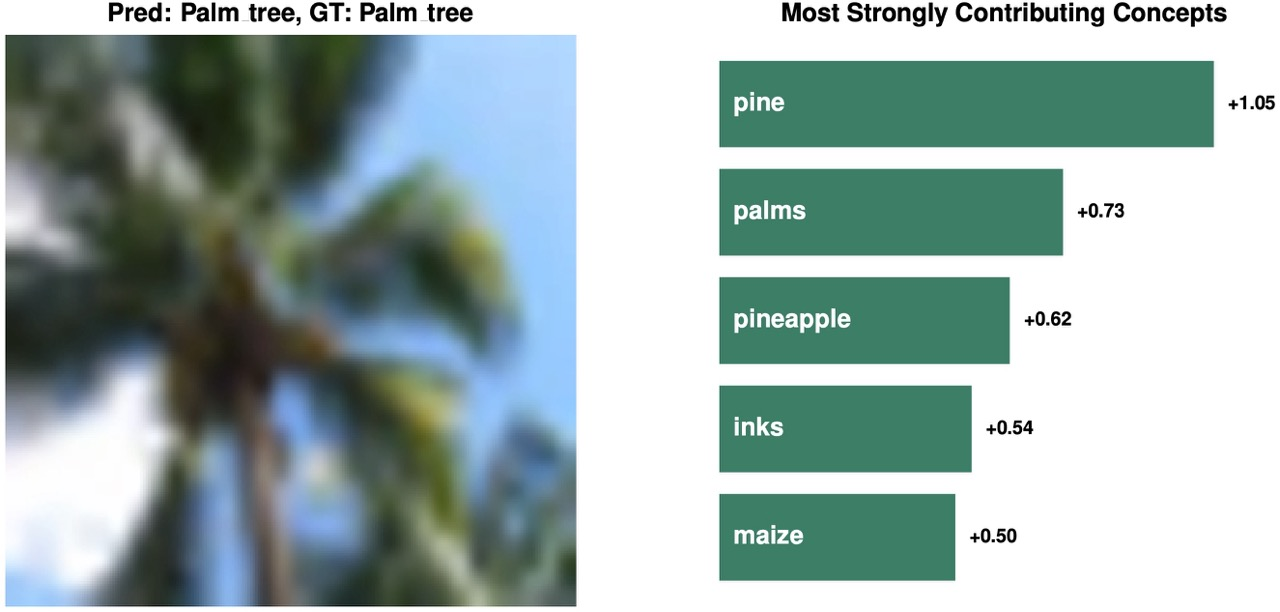

**ImageNet**
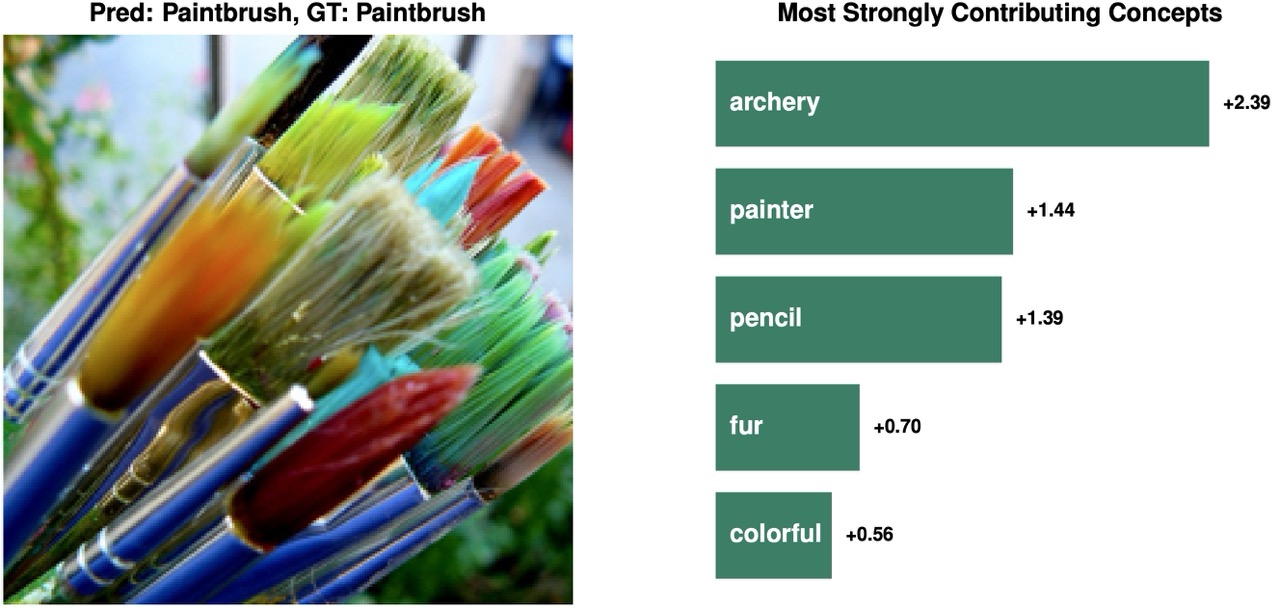

**Places365**
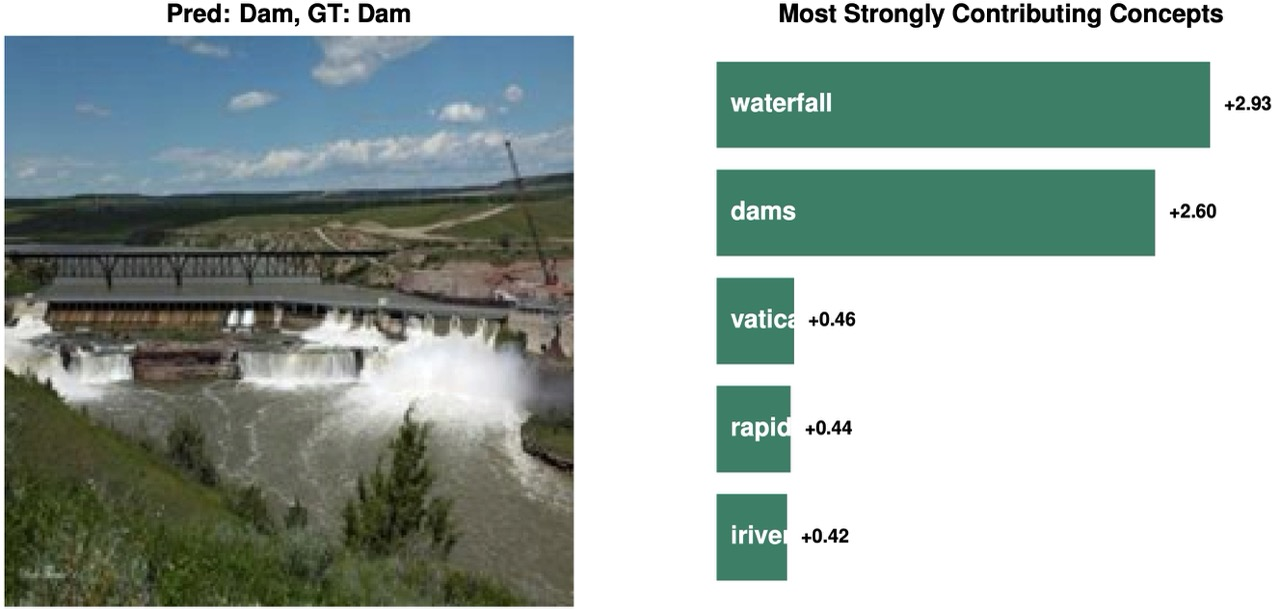

Global explanations

**CIFAR10**
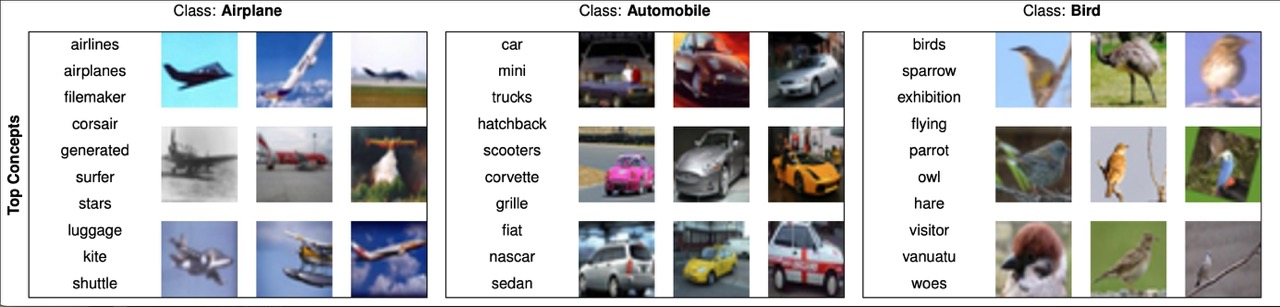

****
**CIFAR100**
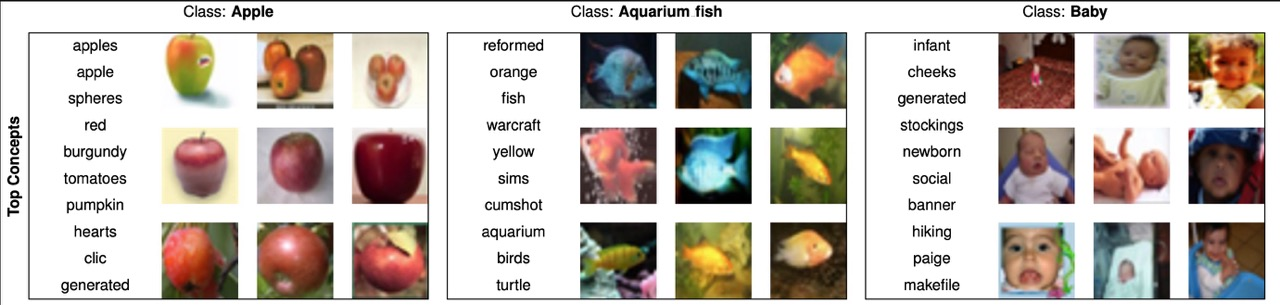

****
**ImageNet**
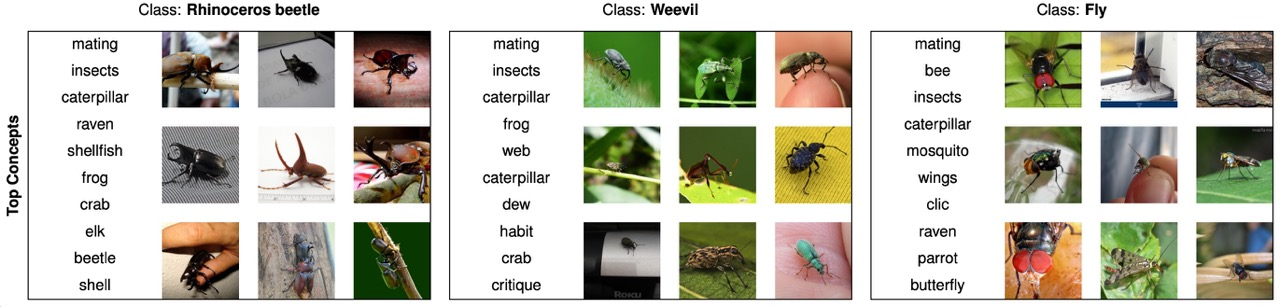

****
**Places365**
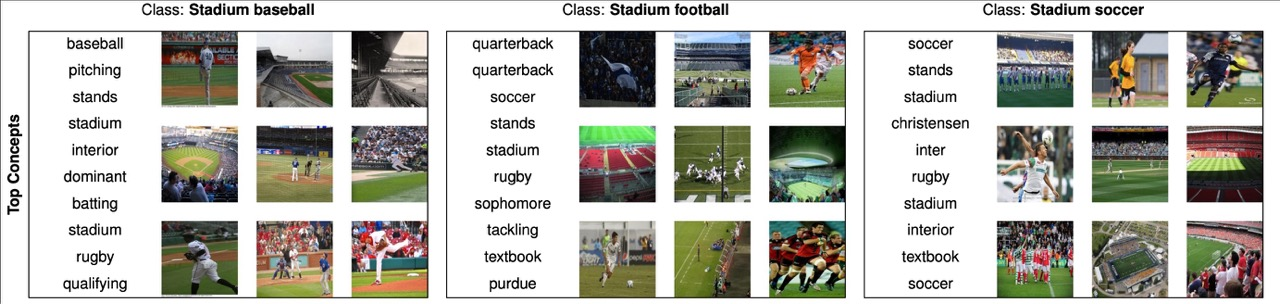

# Extension: Analysis of the learned concept space
This section of the notebook contains the code of Section 4.2.1 Understanding the learned concept space using different vocabularies.

# Distinct named concepts
We first compute the percentage of concepts that are repated accros the three vocabularies:

- 20K Vocabulary: Contains 20,000 common English words. Words are tokenized, stemmed, stop words removed, and encoded [Link](https://github.com/first20hours/google-10000-english/blob/master/20k.txt).

 - Concreteness Ratings: Contains concreteness ratings for 37,058 English words and 2,896 two-word expressions rated in an abstract (1) to concrete (5) scale [Link](https://link.springer.com/article/10.3758/s13428-013-0403-5).

 - WordNet Vocabulary \cite{wordnet}. Contains over 155,000 words hierarchized into synonym sets (synsets). Words are tokenized, stemmed, encoded, and hierarchical relationships are represented as directed acyclic graphs [Link](https://wordnet.princeton.edu/).


In [ ]:
concept_names_20k = pd.read_csv('content/data/concept_names_clipdissect.csv', names=['Neuron', 'Word', 'Similarity'])
concept_names_40k = pd.read_csv('content/data/concept_names_concreteness_rn50.csv', names=['Neuron', 'Word', 'Similarity'])
concept_names_155k = pd.read_csv('content/data/concept_names_wordnet.csv', names=['Neuron', 'Word', 'Similarity'])
unique_concepts_20k = concept_names_20k['Word'].nunique()
unique_concepts_40k = concept_names_40k['Word'].nunique()
unique_concepts_155k = concept_names_155k['Word'].nunique()
num_concepts = len(concept_names_20k)

print('Unique neurons in 40k dataset:',f"({100-(unique_concepts_20k / num_concepts) * 100:.2f}%)")
print('Unique neurons in 40k dataset:',f"({100-(unique_concepts_40k / num_concepts) * 100:.2f}%)")
print('Unique neurons in 155k dataset:', f"({100-(unique_concepts_155k / num_concepts) * 100:.2f}%)")

Unique neurons in 40k dataset: (54.47%)
Unique neurons in 40k dataset: (48.44%)
Unique neurons in 155k dataset: (31.84%)


#Abstract vocabulary

In [11]:
# Use LaTeX for text rendering
plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 14  # Increase font size
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

# Alignment
We compute the alignment of the learned concepts and their corresponding assigned names.

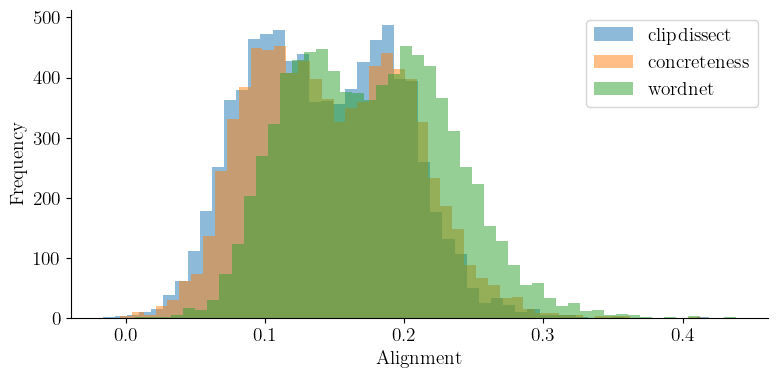

In [12]:
vocabs = {
    'clipdissect': '/content/data/concept_names_clipdissect.csv',
    'concreteness': '/content/data/concept_names_concreteness_rn50.csv',
    'wordnet': '/content/data/concept_names_wordnet.csv'
}

plt.figure(figsize=(8, 4))
concept_names_list = []
for dataset in vocabs.keys():
    concept_names = pd.read_csv(vocabs[dataset], names=['Neuron', 'Word', 'Similarity'])
    concept_names_list.append(concept_names)
    plt.hist(concept_names['Similarity'], bins=50, label=dataset, alpha=0.5)
plt.xlabel('Alignment')
plt.ylabel('Frequency')
plt.legend()
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
alignments = []
vocab_sizes = []
for concept_names in concept_names_list:
    alignments.append(concept_names['Similarity'].mean())
alignments

[0.14313039606520306, 0.14896354135328238, 0.17593116514109397]

# Abstract vocabulary
We now plot the distribution of concrete to abstract names in the concreteness vocabulary as well as for the concept spaces of CLIP ResNet-15 and CLIP ViT/B-16.

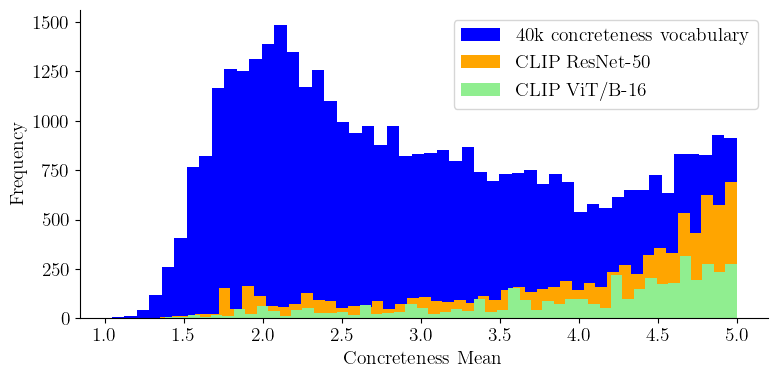

In [ ]:
# Open concreteness voabulary
concreteness_vocab = pd.read_excel('/content/data/Brysbaert.xlsx', sheet_name=0)

# Open concept names using concreteness voabulary
concept_names_rn50 = pd.read_csv('/content/data/concept_names_concreteness_rn50.csv', names=['Neuron', 'Word', 'Similarity'])
concept_names_rn50 = pd.merge(concept_names_rn50, concreteness_vocab, left_on='Word', right_on='Word', how='inner')

concept_names_vit16 = pd.read_csv('/content/data/concept_names_concreteness_vit16.csv', names=['Neuron', 'Word', 'Similarity'])
concept_names_vit16 = pd.merge(concept_names_vit16, concreteness_vocab, left_on='Word', right_on='Word', how='inner')

# Sort by concreteness mean
concept_names_rn50 = concept_names_rn50.sort_values(by='Conc.M', ascending=False)
concept_names_vit16 = concept_names_vit16.sort_values(by='Conc.M', ascending=False)

# Plot histogram of concreteness
plt.figure(figsize=(8, 4))
plt.hist(concreteness_vocab['Conc.M'], bins=50, color='blue', label='40k concreteness vocabulary')
plt.hist(concept_names_rn50['Conc.M'], bins=50, color='orange', label='CLIP ResNet-50')
plt.hist(concept_names_vit16['Conc.M'], bins=50, color='lightgreen', label='CLIP ViT/B-16')
plt.xlabel('Concreteness Mean')
plt.ylabel('Frequency')
plt.legend()
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

We can observe that even though the vocabulary contains more abstract words, the learned concepts by the SAE are strongly distributed towards
the more concrete ratings.
Moreover, given that there is little correlation between concreteness and concept alignment (see next cell) we can conclude that concepts learned by DN-CBMs will be mostly human-interpretable, given the tendency of the SAE to learn concrete concepts.

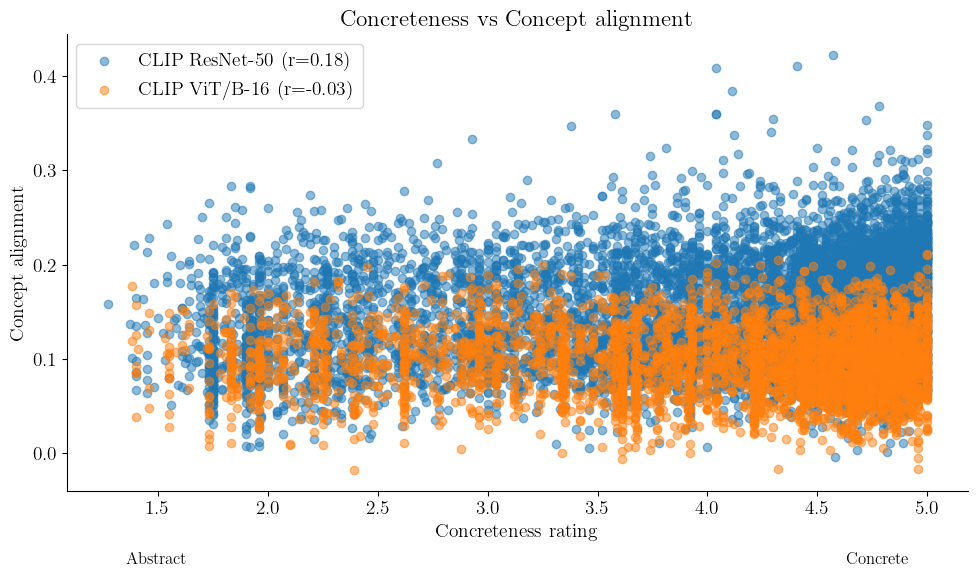

In [ ]:
from scipy.stats import pearsonr

# Calculate Pearson correlation coefficients
pearson_rn50, _ = pearsonr(concept_names_rn50['Conc.M'], concept_names_rn50['Similarity'])
pearson_vit16, _ = pearsonr(concept_names_vit16['Conc.M'], concept_names_vit16['Similarity'])

plt.figure(figsize=(10, 6))
plt.scatter(concept_names_rn50['Conc.M'], concept_names_rn50['Similarity'], alpha=0.5, label=f'CLIP ResNet-50 (r={pearson_rn50:.2f})')
plt.scatter(concept_names_vit16['Conc.M'], concept_names_vit16['Similarity'], alpha=0.5, label=f'CLIP ViT/B-16 (r={pearson_vit16:.2f})')
plt.xlabel('Concreteness rating')
plt.ylabel('Concept alignment')
plt.legend()
plt.title('Concreteness vs Concept alignment')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.annotate('Abstract', xy=(0.1, -0.15), xycoords='axes fraction', fontsize=12,
             ha='center', va='center')
plt.annotate('Concrete', xy=(0.9, -0.15), xycoords='axes fraction', fontsize=12,
             ha='center', va='center')
plt.tight_layout()
plt.show()

This finding highlights the advantage of language-agnostic concept discovery over methods that predefine concept names, and em-
phasizes the need to take into account the discrepancy in abstraction levels between vision and language.

# Polysemanticity
We now study polysemanticity of the concept space and its effect in classification.

In [ ]:
csv_names = {
    'cifar10': 'probe_dataset_stats/cifar10_test_mean_std.csv',
    'cifar100': 'probe_dataset_stats/cifar100_test_mean_std.csv',
    'places365': 'probe_dataset_stats/places365_test_mean_std.csv',
    'imagenet': 'probe_dataset_stats/imagenet_test_mean_std.csv'
}

wordnet_stats = pd.read_csv('/content/data/wordnet_stats.csv')
concept_names = pd.read_csv('/content/data/concept_names_wordnet.csv', names=['Neuron', 'Word', 'Similarity'])
concept_names = pd.merge(concept_names, wordnet_stats, on='Word', how='inner')

activation_mass = []
for dataset in csv_names.keys():
    activation_stats = pd.read_csv('/content/data/' + csv_names[dataset])
    activation_stats = pd.merge(activation_stats, concept_names, on='Neuron', how='inner')
    added_means_total = activation_stats['mean'].sum()
    added_means_polysemantic = activation_stats[activation_stats['Synset Count'] > 1]['mean'].sum()
    activation_mass.append([dataset, added_means_polysemantic / added_means_total])

activation_mass_df = pd.DataFrame(activation_mass, columns=['Dataset', 'Polysemantic Activation Mass'])
activation_mass_df

,Dataset,Polysemantic Activation Mass
0,cifar10,0.163469
1,cifar100,0.162525
2,places365,0.151918
3,imagenet,0.139464


In [ ]:
csv_names = {
    'cifar10': 'accuracies_polysemanticty/polysemanticity_ablation_cifar10.csv',
    'cifar100': 'accuracies_polysemanticty/polysemanticity_ablation_cifar100.csv',
    'places365': 'accuracies_polysemanticty/polysemanticity_ablation_places365.csv',
    'imagenet': 'accuracies_polysemanticty/polysemanticity_ablation_imagenet.csv',
}

accuracies_top1 = []
for dataset in csv_names.keys():
    accuracies = pd.read_csv('/content/data/' + csv_names[dataset])
    accuracies_top1.append([dataset, accuracies['acc_top1'][0]])

accuracies_top1_df = pd.DataFrame(accuracies_top1, columns = ['Dataset', 'Top1 accuracy after prunning'])
accuracies_top1_df

,Dataset,Top1 accuracy after prunning
0,cifar10,0.857900
1,cifar100,0.650700
2,places365,0.495068
3,imagenet,0.706500


We employ WordNet to analyze the presence of polysemantic concepts learned by the SAE and the effect these
have in classification. In particular, we define a word as polysemantic if it belongs to more than one
synonym set and monosemantic if it belongs to only one. Under this definition, more than 21% of lemmas in
WordNet are polysemantic, whereas fewer than 13% of the named concepts learned using CLIP ResNet-50
are polysemantic, showing that the SAE prioritized monosemantic concepts.

Percentage of polysemantic words in WordNet: 0.21487258791097963
Number of polysemantic words in concept names: 1013
Numer of monosemantic words in concept names: 7179
Percentage of polysemantic words in concept names: 0.1236572265625


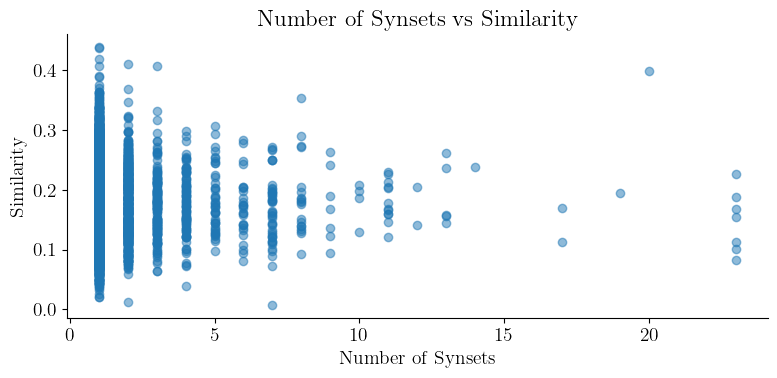

Average similarity for monosemantic words: 0.1765753337079135
Average similarity for polysemantic words: 0.17584026908897135


In [ ]:
wordnet_stats = pd.read_csv('/content/data/wordnet_stats.csv')
concept_names = pd.read_csv('/content/data/concept_names_wordnet.csv', names=['Neuron', 'Word', 'Similarity'])
concept_names = pd.merge(concept_names, wordnet_stats, on='Word', how='inner')

percentage_polysemantic = (
    wordnet_stats[wordnet_stats['Synset Count'] > 1].shape[0]
    / wordnet_stats.shape[0]
)
print('Percentage of polysemantic words in WordNet:', percentage_polysemantic)

count_polysemantic_concept_names = concept_names[concept_names['Synset Count'] > 1].shape[0]
print('Number of polysemantic words in concept names:', count_polysemantic_concept_names)
print('Numer of monosemantic words in concept names:', concept_names.shape[0] - count_polysemantic_concept_names)
percentage_polysemantic_concept_names = count_polysemantic_concept_names / concept_names.shape[0]
print('Percentage of polysemantic words in concept names:', percentage_polysemantic_concept_names)

# Number of synsets vs similarity
plt.figure(figsize=(8, 4))
plt.scatter(concept_names['Synset Count'], concept_names['Similarity'], alpha=0.5)
plt.xlabel('Number of Synsets')
plt.ylabel('Similarity')
plt.title('Number of Synsets vs Similarity')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# Compute average similarity for each number of synsets
print(
    'Average similarity for monosemantic words:',
    concept_names[concept_names['Synset Count'] > 1]['Similarity'].mean(),
)

print(
    'Average similarity for polysemantic words:',
    concept_names[concept_names['Synset Count'] == 1]['Similarity'].mean(),
)

To further understand polysemanticity we named the concepts every three epochs during the training of the SAE and discovered that polysemanticity increases throughout training:

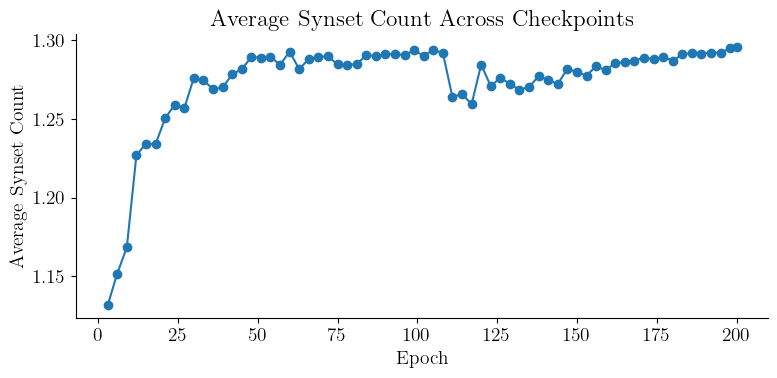

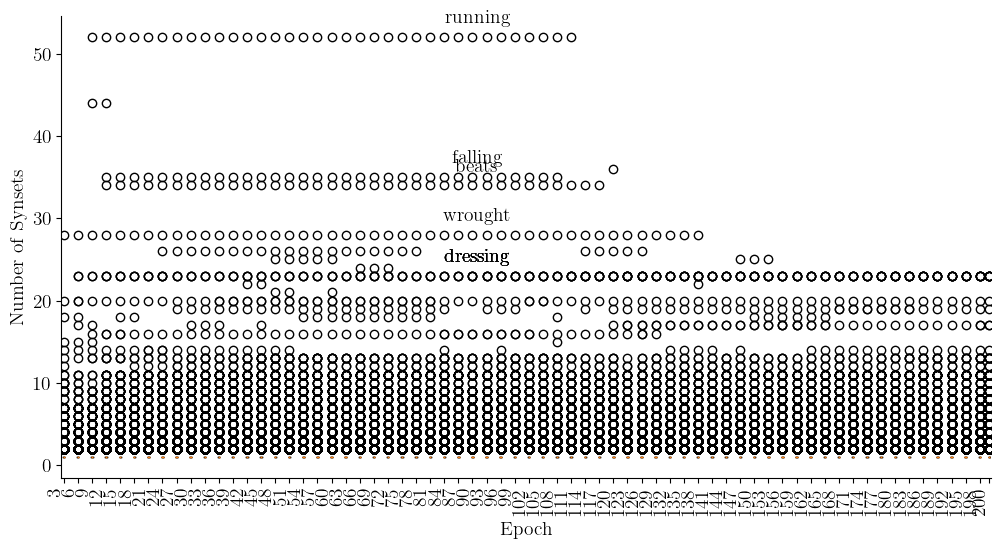

In [ ]:
wordnet_stats = pd.read_csv('/content/data/wordnet_stats.csv')
concept_names = pd.read_csv('/content/data/wordnet_chkpts/concept_names_0.csv', names=['Neuron', 'Word', 'Similarity'])
concept_names = pd.merge(concept_names, wordnet_stats, on='Word', how='inner')

num_chkpts = 66
synset_count, concept_names_ckpts = [], []
for i in range(1, num_chkpts + 1):
    chkpt_path = f'concept_names_{i}.csv'
    current_concept_names = pd.read_csv('/content/data/wordnet_chkpts/' + chkpt_path, names=['Neuron', 'Word', 'Similarity'])
    current_concept_names = current_concept_names.merge(wordnet_stats, on='Word', how='inner')
    concept_names_ckpts.append(current_concept_names)
    synset_count.append(current_concept_names['Synset Count'].mean())
concept_names_ckpts.append(concept_names)
synset_count.append(concept_names['Synset Count'].mean())

plt.figure(figsize=(8, 4))
x_axis = list(range(3, 3*(num_chkpts + 1), 3))
x_axis.append(200)
plt.plot(x_axis, synset_count, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Average Synset Count')
plt.title('Average Synset Count Across Checkpoints')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

synset_counts = [concept_names_ckpts[i]['Synset Count'] for i in range(num_chkpts + 1)]
plt.figure(figsize=(12, 6))
boxplot = plt.boxplot(synset_counts, positions=x_axis, patch_artist=True)
# Annotate outliers
for i in range(num_chkpts + 1):
    for outlier in boxplot['fliers'][i].get_ydata():
        if outlier > 20 and i == 30:
            word = concept_names_ckpts[i][concept_names_ckpts[i]['Synset Count'] == outlier]['Word'].values[0]
            plt.annotate(word, (3*i + 1, outlier), textcoords="offset points", xytext=(0,10), ha='center')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.xlabel('Epoch')
plt.xticks(rotation=90, ha='right')
plt.ylabel('Number of Synsets')
# plt.title('Number of Synsets in Concept Names at Each Checkpoint')
plt.show()

#User study

In [ ]:
df = pd.read_csv('content/data/User_study2.csv')

# Define the mapping for the scores
score_mapping = {
    "Strongly disagree": 1,
    "Somewhat disagree": 2,
    "Neither agree nor disagree": 3,
    "Somewhat agree": 4,
    "Strongly agree": 5
}


# Drop the timestamp column (first column)
df = df.iloc[:, 1:]

# Rename columns to desired format (Word + Semantic Consistency/Name Accuracy)
new_columns = []
for col in df.columns:
    if "Semantic consistency" in col:
        word = col.split(":")[1].strip()
        new_columns.append(word)
    elif "Name accuracy" in col:
        word = col.split(":")[1].strip()
        new_columns.append(word)
df.columns = new_columns

# Map the responses to numeric values
df = df.replace(score_mapping)

# Output the transformed dataset
print(df.shape)
df

(26, 30)


<ipython-input-45-3a0a7d907f7e>:28: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(score_mapping)


,Gazette\nSemantic consistency,Gazette\nName accuracy,Alcoholic\nSemantic consistency,Alcoholic\nName accuracy,Gray\nSemantic consistency,Gray\nName accuracy,Unavailable\nSemantic consistency,Unavailable\nName accuracy,Turquoise\nSemantic consistency,Turquoise\nName accuracy,...,Audience\nSemantic consistency,Audience\nName accuracy,Landscaping\nSemantic consistency,Landscaping\nName accuracy,Firefighter\nSemantic consistency,Firefighter\nName accuracy,Lama\nSemantic consistency,Lama\nName accuracy,Altar\nSemantic consistency,Altar\nName accuracy
0,1,1,5,5,5,5,1,1,4,4,...,5,5,4,4,5,5,4,4,1,1
1,1,1,5,5,5,5,1,1,5,4,...,4,2,1,1,4,4,4,4,1,1
2,2,1,5,5,5,5,1,1,5,5,...,4,4,4,1,4,4,5,5,3,2
3,1,1,5,2,5,5,1,1,5,5,...,5,5,5,5,5,5,5,5,1,1
4,1,2,5,5,4,5,1,1,4,5,...,4,4,3,4,5,5,4,3,3,2
5,1,1,5,5,4,5,1,3,5,5,...,4,5,3,2,5,4,4,4,2,1
6,1,1,5,4,5,5,1,2,4,5,...,5,5,2,1,4,4,4,4,2,1
7,1,1,5,5,5,5,1,1,5,5,...,4,4,2,2,5,5,4,2,2,1
8,1,1,5,5,5,5,1,1,5,5,...,5,4,4,2,5,4,4,2,4,1
9,1,1,5,4,4,5,1,1,4,5,...,4,4,2,2,5,5,4,2,1,1


In [ ]:
# Reordering the columns
idx =  [12, 7, 4, 15, 3, 10, 2, 8, 5, 14, 1, 11, 6, 9, 13]
position_list = [idx.index(i) for i in range(1,16) ]
print(position_list)
idx = []
for i in position_list:
    idx.append(i*2)
    idx.append(i*2+1)

df = df.iloc[:, idx]
df

[10, 6, 4, 2, 8, 12, 1, 7, 13, 5, 11, 0, 14, 9, 3]


,new_column_name,new_column_name2,Roundtable\nSemantic consistency,Roundtable\nName accuracy,Turquoise\nSemantic consistency,Turquoise\nName accuracy,Gray\nSemantic consistency,Gray\nName accuracy,Stairs\nSemantic consistency,Stairs\nName accuracy,...,Landscaping\nSemantic consistency,Landscaping\nName accuracy,Gazette\nSemantic consistency,Gazette\nName accuracy,Altar\nSemantic consistency,Altar\nName accuracy,Polaroid\nSemantic consistency,Polaroid\nName accuracy,Unavailable\nSemantic consistency,Unavailable\nName accuracy
0,5,5,2,2,4,4,5,5,5,5,...,4,4,1,1,1,1,1,1,1,1
1,4,2,4,4,5,4,5,5,5,4,...,1,1,1,1,1,1,1,1,1,1
2,4,4,4,4,5,5,5,5,5,5,...,4,1,2,1,3,2,3,2,1,1
3,5,5,4,5,5,5,5,5,5,5,...,5,5,1,1,1,1,1,1,1,1
4,4,4,4,4,4,5,4,5,5,5,...,3,4,1,2,3,2,2,4,1,1
5,4,5,5,5,5,5,4,5,5,5,...,3,2,1,1,2,1,1,1,1,3
6,5,5,4,3,4,5,5,5,5,4,...,2,1,1,1,2,1,2,1,1,2
7,4,4,4,4,5,5,5,5,5,5,...,2,2,1,1,2,1,1,1,1,1
8,5,4,4,2,5,5,5,5,5,5,...,4,2,1,1,4,1,2,1,1,1
9,4,4,4,4,4,5,4,5,4,4,...,2,2,1,1,1,1,1,1,1,1


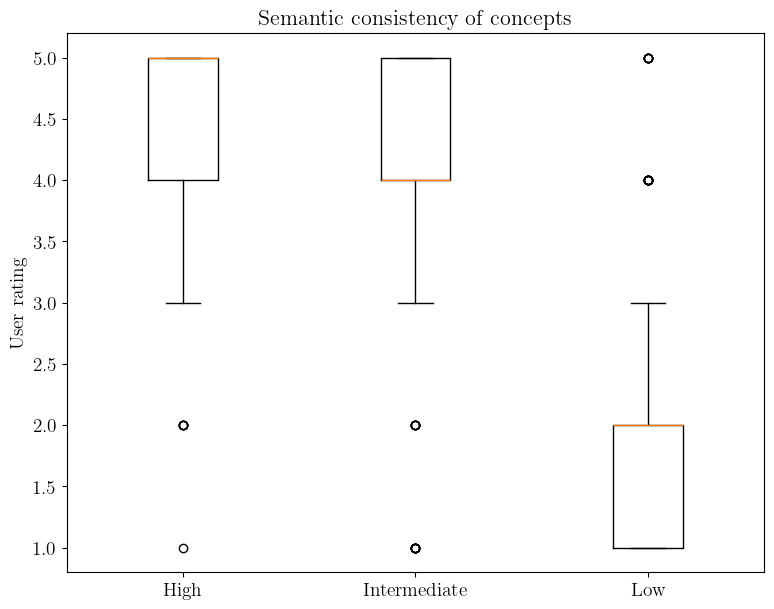

In [ ]:
import seaborn as sns

# Example data
high = df.iloc[:, [0, 2, 4, 6, 8]].values.flatten().tolist()
mid = df.iloc[:,[10,12,14,16,18]].values.flatten().tolist()
low = df.iloc[:, [20,22,24,26,28]].values.flatten().tolist()

# Create a box plot for all three lists
plt.figure(figsize=(9,7))

plt.boxplot([high, mid, low])

# Add labels and title
plt.title("Semantic consistency of concepts", fontsize=16,fontweight='bold')
plt.ylabel("User rating",fontweight='bold', fontsize=14)
plt.xticks([1, 2, 3], ['High', 'Intermediate', 'Low'],fontweight='bold', fontsize=14)  # Add custom x-axis labels

# Display the plot
plt.show()

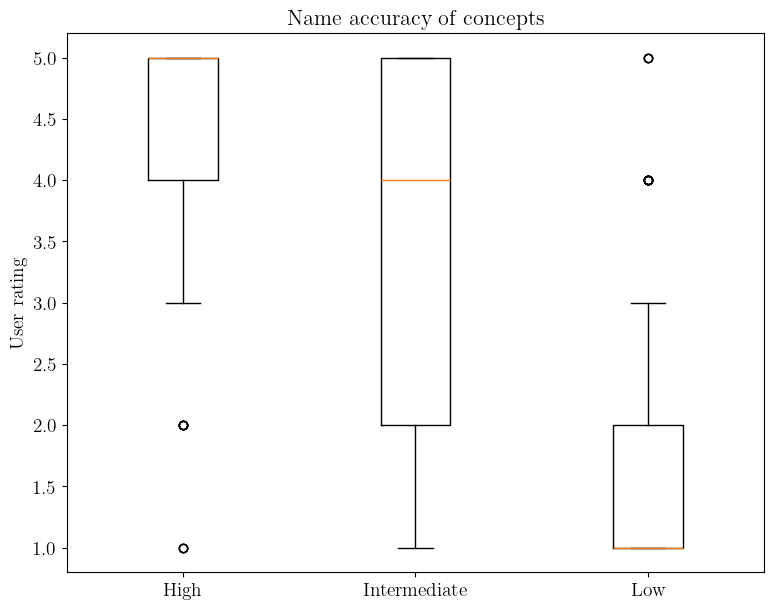

In [ ]:

# Example data
high = df.iloc[:, [1,3,5,7]].values.flatten().tolist()
mid = df.iloc[:,[11,13,15,17,19]].values.flatten().tolist()
low = df.iloc[:, [21,23,25,27,29]].values.flatten().tolist()

# Create a box plot for all three lists
plt.figure(figsize=(9,7))
plt.boxplot([high, mid, low])

# Add labels and title
plt.title("Name accuracy of concepts", fontsize=16,fontweight='bold')
plt.ylabel("User rating", fontweight='bold', fontsize=14)
plt.xticks([1, 2, 3], ['High', 'Intermediate', 'Low'], fontweight='bold', fontsize=14)  # Add custom x-axis labels

# Display the plot
plt.show()

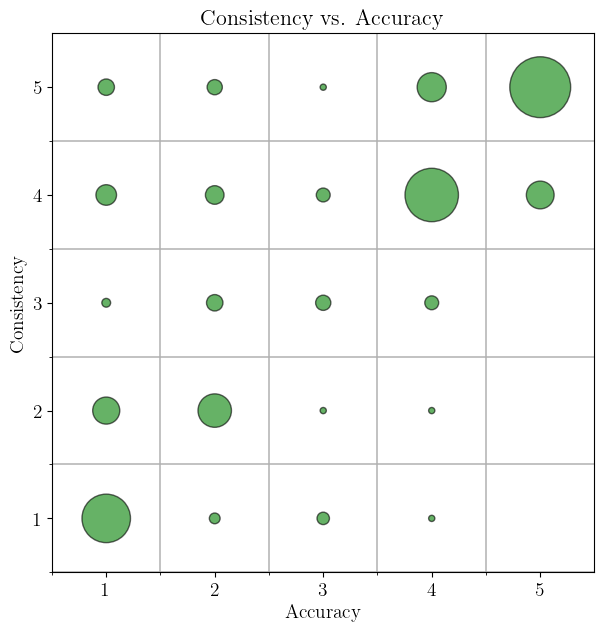

In [ ]:
import numpy as np
from collections import Counter

similarity = df.iloc[:, list(range(0,30,2))].values.flatten().tolist() # consistency
accuracy = df.iloc[:, list(range(1,30,2))].values.flatten().tolist()


# Count occurrences of each (accuracy, similarity) pair
pairs = list(zip(accuracy, similarity))
counts = Counter(pairs)  # Dictionary {(x,y): frequency}

# Extract unique pairs and their counts
x_vals, y_vals, sizes = zip(*[(x, y, counts[(x, y)] * 20) for x, y in counts])  # Scale factor 200

# Create scatter plot (bubble chart)
plt.figure(figsize=(7,7))
plt.scatter(x_vals, y_vals, s=sizes, c='green', alpha=0.6, edgecolors='black')

# Grid & Labels
plt.gca().set_xticks(np.arange(0.5, 5.5, 1), minor=True)
plt.gca().set_yticks(np.arange(0.5, 5.5, 1), minor=True)
plt.grid(visible=True, which='minor', linestyle='-', linewidth=1.2, alpha=0.9)
plt.xlabel("Accuracy", fontsize=14, fontweight='bold')
plt.ylabel("Consistency", fontsize=14, fontweight='bold')
plt.title("Consistency vs. Accuracy", fontsize=16, fontweight='bold')

# Set axis limits and ticks

plt.xlim(0.5, 5.5)
plt.ylim(0.5, 5.5)

# Show plot
plt.show()


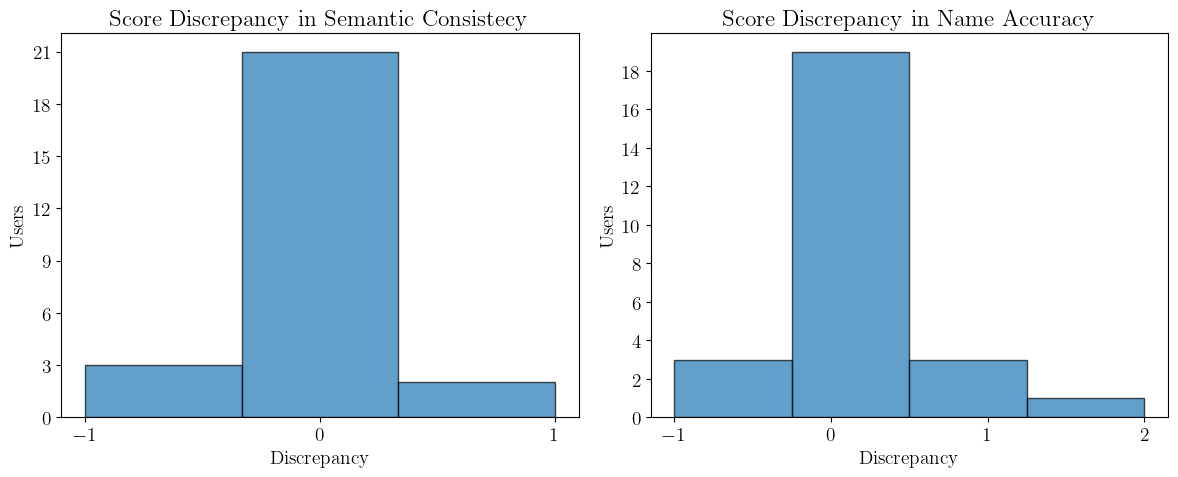

In [ ]:
from matplotlib.ticker import MaxNLocator

# Check for discrepancy
# First rename the double concept
cols = list(df.columns)
duplicate_index = [i for i, col in enumerate(cols) if col == "Audience\nName accuracy"]

# Rename the second occurrence (index 1 in the duplicate list)
if len(duplicate_index) > 1:
    cols[duplicate_index[1]] = "new_column_name2"

duplicate_index = [i for i, col in enumerate(cols) if col == "Audience\nSemantic consistency"]

# Rename the second occurrence (index 1 in the duplicate list)
if len(duplicate_index) > 1:
    cols[duplicate_index[1]] = "new_column_name"

df.columns = cols

lista = df["Audience\nSemantic consistency"]-df["new_column_name"]
lista2 = df["Audience\nName accuracy"]-df["new_column_name2"]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns

# Plot the first histogram
axes[0].hist(lista, bins=len(set(lista)), edgecolor='black', alpha=0.7)
axes[0].set_title("Score Discrepancy in Semantic Consistecy", fontweight='bold')

axes[0].xaxis.set_major_locator(MaxNLocator(integer=True))
axes[0].yaxis.set_major_locator(MaxNLocator(integer=True))
axes[0].set_xlabel("Discrepancy")
axes[0].set_ylabel("Users")

# Plot the second histogram
axes[1].hist(lista2, bins=len(set(lista2)), edgecolor='black', alpha=0.7)
axes[1].set_title("Score Discrepancy in Name Accuracy", fontweight='bold')
axes[1].xaxis.set_major_locator(MaxNLocator(integer=True))
axes[1].yaxis.set_major_locator(MaxNLocator(integer=True))
axes[1].set_xlabel("Discrepancy")
axes[1].set_ylabel("Users")
# Show the figure
plt.tight_layout()
plt.show()